# NB11f: NB11 Hyperparameter Analysis (v1)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Reads NB11 hyperparameter-tuning results from `OUTPUTS_DIR / NB11_V2 / best_params / *.json`.
Surfaces what Optuna actually learned: which hyperparameters drifted away from the source defaults, which correlate with bigger lifts, and how fast each search converged.

**Question this answers:** what did 200 trials of TPE actually buy us? Is there a generalizable hyperparameter recipe across parquets, or does each parquet need its own configuration?

**Outputs:**
- `cell_m1/M1_best_params_table.csv`        -- one row per study
- `cell_m2/M2_param_distributions.csv`      -- per-classifier param distributions
- `cell_m3/M3_drift_from_defaults.csv`      -- how far tuned params moved from source defaults
- `cell_m4/M4_param_vs_delta_corr.csv`      -- which param changes explain lift
- `cell_m5/M5_param_vs_dataset.csv`         -- param vs n_features / n_buildings / n_cities
- `cell_m6/M6_convergence.csv`              -- trial-where-best-found per study
- `cell_m7/summary.json`

## CELL 1 -- CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 1: NB11f CONFIG + GLOBAL SETUP
TIER_SELECTION = [0, 1, 2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

OUT_DIR = RESULTS_ROOT / 'nb11f'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# NB11 hyperparameter results location
NB11_V2_DIR        = OUTPUTS_DIR / 'NB11_V2'
NB11_BEST_PARAMS   = NB11_V2_DIR / 'best_params'
NB11_OOF_DIR       = NB11_V2_DIR / 'oof'

from datetime import datetime as _dt
import pandas as pd
import numpy as np
import json as _json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

import sys
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from bda_results import ResultRegistry

print(f"  OUT_DIR:           {OUT_DIR}")
print(f"  NB11_V2_DIR:       {NB11_V2_DIR}")
print(f"  NB11_BEST_PARAMS:  {NB11_BEST_PARAMS}  exists={NB11_BEST_PARAMS.exists()}")
print(f"  NB11_OOF_DIR:      {NB11_OOF_DIR}  exists={NB11_OOF_DIR.exists()}")
print(f"  REGISTRY_DIR:      {RESULTS_ROOT / 'registry'}")


BDA GLOBAL SETUP
Started: 2026-07-03 08:44:18
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     930.7/7452.0 GB (6521.3 GB free)
  GDrive (F:)     1405.7/3726.0 GB (2320.3 GB free)
  Local data      11563.4/14901.9 GB (3338.4 GB free)
  Data stack      1405.7/3726.0 GB (2320.3 GB free)
  WSL ext4        69.1/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

## CELL S0 -- LOAD NB11 BEST_PARAMS + HELPERS

In [2]:
# @title CELL S0: LOAD NB11 BEST_PARAMS JSONS + HELPERS
print("=" * 70)
print("CELL S0: LOAD NB11 BEST_PARAMS")
print("=" * 70)

BP_FILES = sorted(NB11_BEST_PARAMS.glob('*.json')) if NB11_BEST_PARAMS.exists() else []
print(f"  NB11 best_params JSON files: {len(BP_FILES)}")

records = []
for fp in BP_FILES:
    try:
        with open(fp) as f:
            d = _json.load(f)
        rec = {
            'study_tag':           d.get('study_tag'),
            'notebook':            d.get('notebook'),
            'manifest_key':        d.get('manifest_key'),
            'parquet_id':          d.get('parquet_id'),
            'feature_set':         d.get('feature_set'),
            'classifier':          d.get('classifier'),
            'baseline_auc':        d.get('baseline_auc'),
            'tuned_auc':           d.get('tuned_auc'),
            'delta_auc':           d.get('delta_auc'),
            'mean_folds_auc':      d.get('mean_folds_auc'),
            'std_folds_auc':       d.get('std_folds_auc'),
            'fold_aucs':           d.get('fold_aucs'),
            'n_trials_done':       d.get('n_trials_done'),
            'n_trials_requested':  d.get('n_trials_requested'),
            'patience':            d.get('patience'),
            'n_features':          d.get('n_features'),
            'n_buildings':         d.get('n_buildings'),
            'n_cities':            d.get('n_cities'),
        }
        # Inline best_params dict columns with prefix
        bp = d.get('best_params', {}) or {}
        for k, v in bp.items():
            rec[f'p_{k}'] = v
        rec['_path'] = str(fp)
        records.append(rec)
    except Exception as e:
        print(f"  WARN: could not load {fp.name}: {e}")

BP_DF = pd.DataFrame(records) if records else pd.DataFrame()
print(f"  Loaded {len(BP_DF)} tuned studies")

# --- helpers (duplicated from 11e to keep 11f standalone) ------------
def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            _json.dump(data, fh, indent=2, default=str)
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

import matplotlib.pyplot as plt

def save_fig(fig, name, cell_id, dpi=150, show=True):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    if show:
        plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

# Source-baseline default hyperparameters (matches BASELINE_TRIALS in NB11 OPTUNA cells)
SOURCE_DEFAULTS = {
    'LightGBM-MIA': {  # from NB08c_v2 v8 LGBM_PARAMS
        'n_estimators': 150, 'num_leaves': 31, 'max_depth': 6,
        'learning_rate': 0.05, 'min_child_samples': 20,
        'reg_alpha': 0.0, 'reg_lambda': 0.0,
        'feature_fraction': 1.0, 'bagging_fraction': 1.0, 'bagging_freq': 0,
    },
    'LightGBM': {  # NB09a v7 R5
        'n_estimators': 200, 'num_leaves': 31, 'max_depth': 7,
        'learning_rate': 0.1, 'min_child_samples': 20,
        'reg_alpha': 0.0, 'reg_lambda': 0.0,
        'feature_fraction': 1.0, 'bagging_fraction': 1.0, 'bagging_freq': 0,
    },
    'XGBoost': {
        'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1,
        'min_child_weight': 1, 'subsample': 1.0, 'colsample_bytree': 1.0,
        'reg_alpha': 0.0, 'reg_lambda': 1.0,
    },
    'RF-200': {
        'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3,
        'min_samples_split': 2, 'max_features': 'sqrt',
    },
    'ExtraTrees': {
        'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 3,
        'min_samples_split': 2, 'max_features': 'sqrt',
    },
}

print(f"\n  SOURCE_DEFAULTS defined for {len(SOURCE_DEFAULTS)} classifier families")


CELL S0: LOAD NB11 BEST_PARAMS
  NB11 best_params JSON files: 31
  Loaded 31 tuned studies

  SOURCE_DEFAULTS defined for 5 classifier families


## CELL M1 -- BEST_PARAMS TABLE

In [3]:
# @title CELL M1: BEST_PARAMS TABLE
print("=" * 70)
print("CELL M1: BEST_PARAMS TABLE")
print("=" * 70)

if len(BP_DF) == 0:
    print("  No best_params files. Nothing to do.")
else:
    main_cols = ['notebook', 'manifest_key', 'classifier',
                 'baseline_auc', 'tuned_auc', 'delta_auc',
                 'mean_folds_auc', 'std_folds_auc',
                 'n_trials_done', 'n_trials_requested',
                 'n_features', 'n_buildings', 'n_cities']
    main_cols = [c for c in main_cols if c in BP_DF.columns]
    param_cols = [c for c in BP_DF.columns if c.startswith('p_')]
    display(BP_DF[main_cols + param_cols].sort_values('tuned_auc', ascending=False))
    save_result(BP_DF[main_cols + param_cols], 'M1_best_params_table', 'cell_m1')


CELL M1: BEST_PARAMS TABLE


,notebook,manifest_key,classifier,baseline_auc,tuned_auc,delta_auc,mean_folds_auc,std_folds_auc,n_trials_done,n_trials_requested,n_features,n_buildings,n_cities,p_n_estimators,p_num_leaves,p_max_depth,p_learning_rate,p_min_child_samples,p_reg_alpha,p_reg_lambda,p_feature_fraction,p_bagging_fraction,p_bagging_freq,p_random_state,p_n_jobs,p_verbose,p_is_unbalance,p_force_col_wise,p_min_samples_leaf,p_min_samples_split,p_max_features,p_min_child_weight,p_subsample,p_colsample_bytree
24,NB11e_dietrich28,block_stats,LightGBM,0.8162,0.8652,0.0490,0.7451,0.0732,81,200,56,598595,21,763,234.0000,3.0000,0.0312,81.0000,0.8145,0.4328,0.8383,0.6775,3.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,NB11e_dietrich28,block_stats,XGBoost,0.8303,0.8565,0.0262,0.7443,0.0743,23,200,56,598595,21,521,NaN,10.0000,0.0106,NaN,0.3636,0.3668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0000,0.9162,0.6062
6,NB11b_A15_block_stats,block_stats,LightGBM-MIA,0.8227,0.8531,0.0305,0.6434,0.1473,49,200,780,598595,21,641,62.0000,3.0000,0.1151,72.0000,1.4580,1.5425,0.5370,0.6792,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NB11a_F4_F7,fusion_ms_cohdrop,LightGBM-MIA,0.8126,0.8514,0.0388,0.7331,0.0488,96,200,88,466704,18,104,157.0000,3.0000,0.1186,75.0000,1.3869,1.8451,0.5795,0.8494,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NB11b_A16_A17_A18_rolling,rolling_stats_roll7,LightGBM-MIA,0.8233,0.8514,0.0281,0.6570,0.1496,49,200,57,598595,21,641,62.0000,3.0000,0.1151,72.0000,1.4580,1.5425,0.5370,0.6792,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NB11a_F2_F6,fusion_indices_card_cohdrop,LightGBM-MIA,0.8154,0.8471,0.0317,0.7481,0.0443,45,200,86,466704,18,174,133.0000,4.0000,0.1404,59.0000,0.6633,1.6569,0.5024,0.6503,8.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NB11a_F3,fusion_card_cohdrop,LightGBM-MIA,0.8417,0.8457,0.0040,0.7242,0.0693,67,200,32,584986,20,206,151.0000,5.0000,0.0168,59.0000,0.0928,1.4692,0.5004,0.6803,2.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,NB11e_dietrich28,block_stats,RF-200,0.6845,0.8452,0.1607,0.7326,0.0898,87,100,56,598595,21,177,NaN,7.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0000,13.0000,log2,NaN,NaN,NaN
3,NB11a_F4_F7,fusion_composite_cohdrop,LightGBM-MIA,0.8130,0.8449,0.0319,0.6783,0.1052,46,200,145,466704,18,185,134.0000,3.0000,0.1524,29.0000,1.3250,0.6234,0.7600,0.7734,2.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,NB11c_A22_lu_change,lu_change,LightGBM-MIA,0.8127,0.8430,0.0302,0.6693,0.1076,97,200,11,598595,21,161,92.0000,4.0000,0.1245,90.0000,1.8020,0.3660,0.5823,0.5788,5.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


  Saved: cell_m1/M1_best_params_table_20260703_084515.csv (8.9 KB)


## CELL M2 -- PARAM DISTRIBUTIONS PER CLASSIFIER

CELL M2: PARAM DISTRIBUTIONS PER CLASSIFIER FAMILY


,classifier,param,n,min,mean,median,max,std,unique_vals
0,ExtraTrees,n_estimators,2,206.0000,391.0000,391.0000,576.0000,261.6295,
1,ExtraTrees,max_depth,1,10.0000,10.0000,10.0000,10.0000,NaN,
2,ExtraTrees,min_samples_leaf,2,7.0000,8.0000,8.0000,9.0000,1.4142,
3,ExtraTrees,min_samples_split,2,2.0000,2.5000,2.5000,3.0000,0.7071,
4,ExtraTrees,max_features,2,,,,,,"{0.3: 1, 'log2': 1}"
5,LightGBM,n_estimators,2,157.0000,460.0000,460.0000,763.0000,428.5067,
6,LightGBM,num_leaves,2,234.0000,241.0000,241.0000,248.0000,9.8995,
7,LightGBM,max_depth,2,3.0000,3.0000,3.0000,3.0000,0.0000,
8,LightGBM,learning_rate,2,0.0113,0.0213,0.0213,0.0312,0.0140,
9,LightGBM,min_child_samples,2,81.0000,87.5000,87.5000,94.0000,9.1924,


  Saved: cell_m2/M2_param_distributions_20260703_084515.csv (3.6 KB)


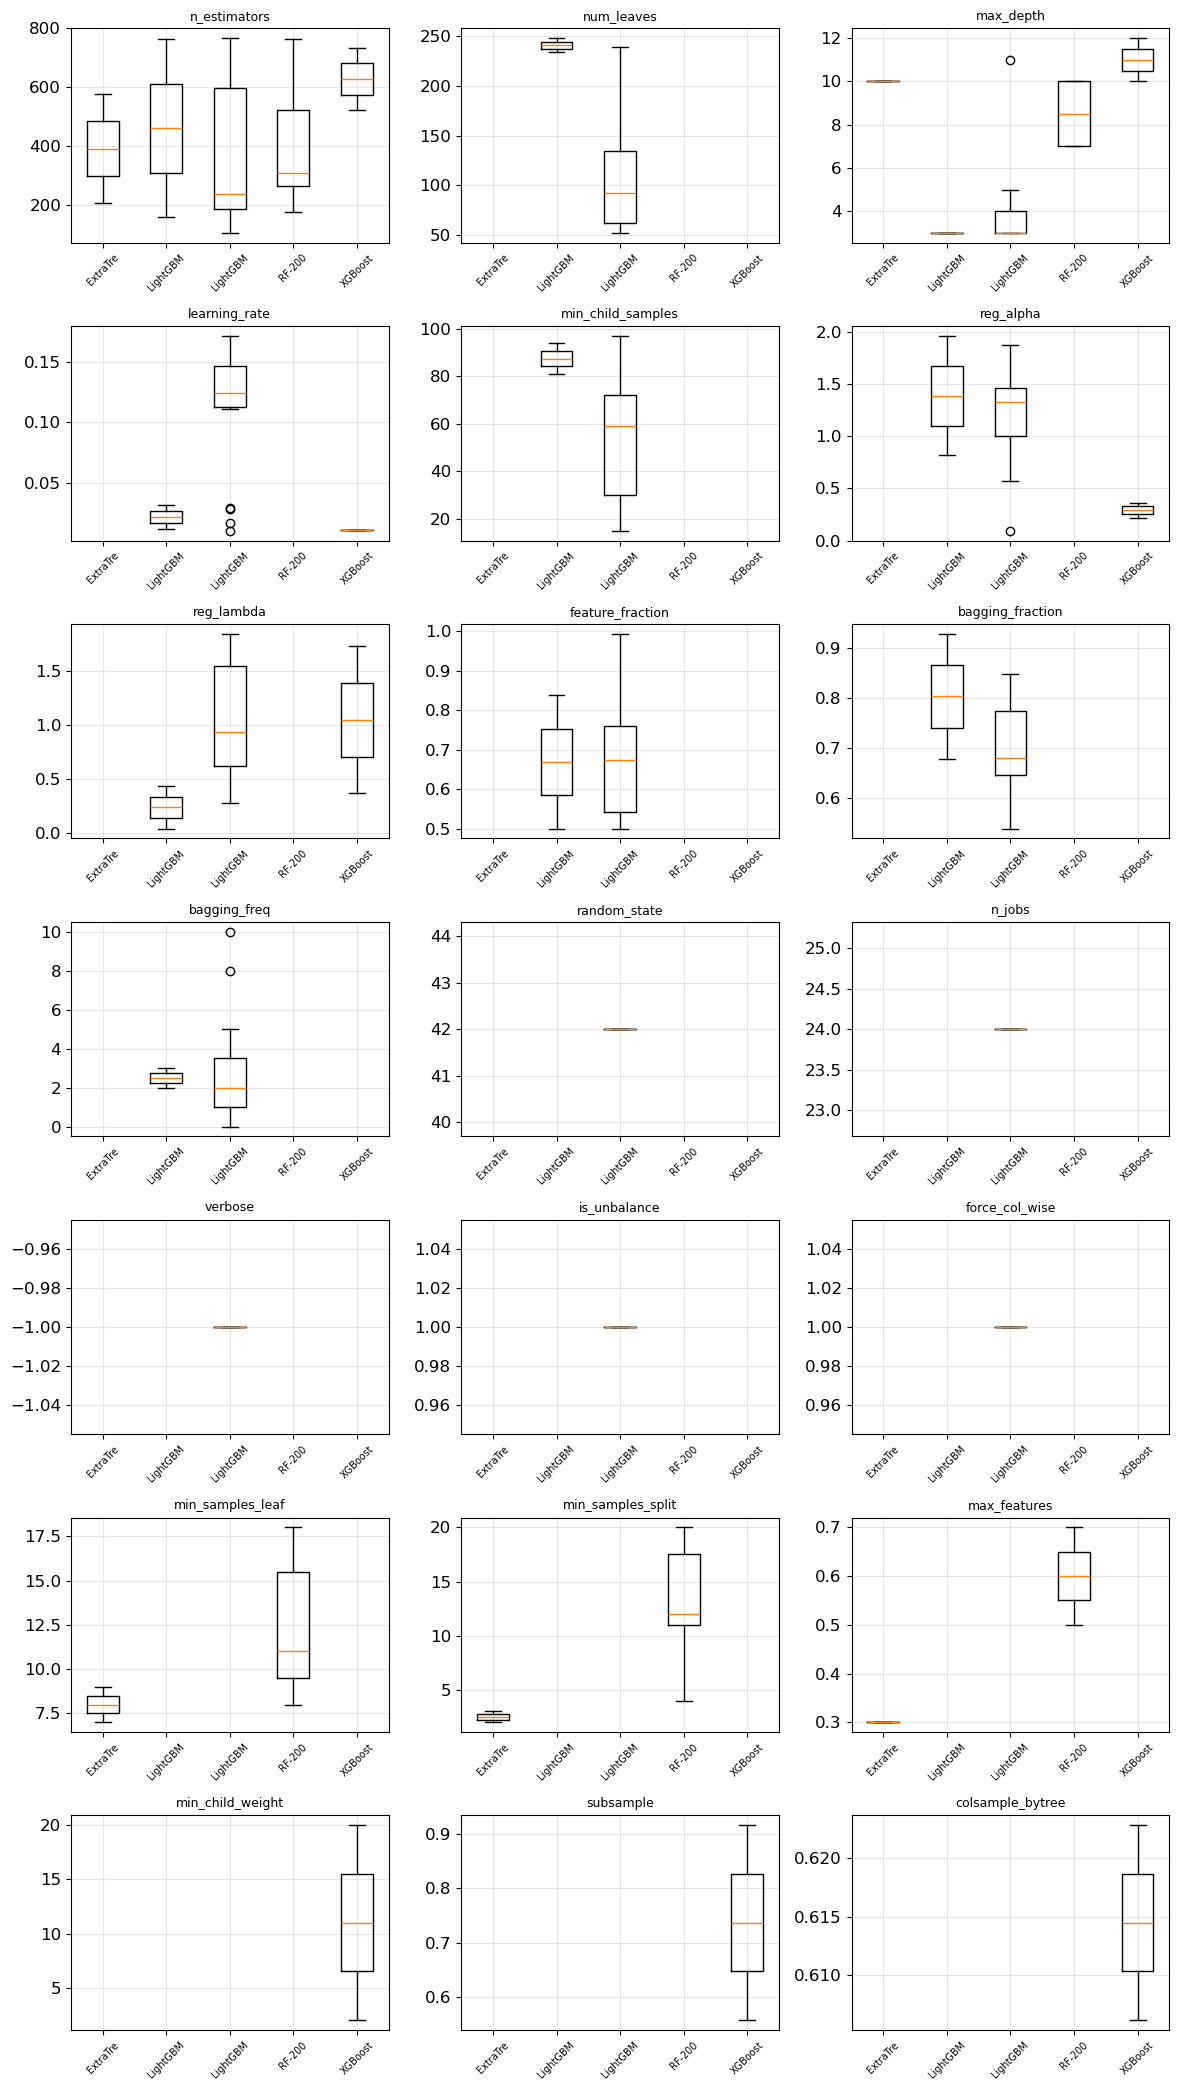

  Plot: cell_m2/M2_param_boxplots_20260703_084516.png


In [4]:
# @title CELL M2: PARAM DISTRIBUTIONS PER CLASSIFIER FAMILY
print("=" * 70)
print("CELL M2: PARAM DISTRIBUTIONS PER CLASSIFIER FAMILY")
print("=" * 70)

if len(BP_DF) == 0:
    print("  Empty BP_DF; skipping.")
else:
    param_cols = [c for c in BP_DF.columns if c.startswith('p_')]
    rows = []
    for clf, sub in BP_DF.groupby('classifier'):
        for pc in param_cols:
            vals = sub[pc].dropna()
            if len(vals) == 0: continue
            # numeric stats
            try:
                vnum = pd.to_numeric(vals)
                rows.append({
                    'classifier': clf, 'param': pc[2:],
                    'n': int(len(vnum)),
                    'min': float(vnum.min()), 'mean': float(vnum.mean()),
                    'median': float(vnum.median()), 'max': float(vnum.max()),
                    'std': float(vnum.std()),
                    'unique_vals': '',
                })
            except (ValueError, TypeError):
                # categorical
                uniq = vals.value_counts().to_dict()
                rows.append({
                    'classifier': clf, 'param': pc[2:],
                    'n': int(len(vals)),
                    'unique_vals': str(uniq),
                    'min': '', 'mean': '', 'median': '', 'max': '', 'std': '',
                })
    DIST_DF = pd.DataFrame(rows)
    if len(DIST_DF) > 0:
        display(DIST_DF)
        save_result(DIST_DF, 'M2_param_distributions', 'cell_m2')

        # Boxplot of numeric params per classifier
        try:
            param_cols_num = [c for c in param_cols
                              if pd.to_numeric(BP_DF[c], errors='coerce').notna().any()]
            classifiers = sorted(BP_DF['classifier'].dropna().unique())
            n_clf = len(classifiers)
            if n_clf > 0 and len(param_cols_num) > 0:
                ncols = min(3, len(param_cols_num))
                nrows = int(np.ceil(len(param_cols_num) / ncols))
                fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
                axes = np.atleast_1d(axes).flatten()
                for ax, pc in zip(axes, param_cols_num):
                    data = [pd.to_numeric(BP_DF[BP_DF['classifier']==c][pc], errors='coerce').dropna().values
                            for c in classifiers]
                    ax.boxplot(data, labels=[c[:8] for c in classifiers])
                    ax.set_title(pc[2:], fontsize=9)
                    ax.tick_params(axis='x', rotation=45, labelsize=7)
                    ax.grid(alpha=0.3)
                for ax in axes[len(param_cols_num):]:
                    ax.axis('off')
                fig.tight_layout()
                save_fig(fig, 'M2_param_boxplots', 'cell_m2')
                plt.close(fig)
        except Exception as e:
            print(f"  Plot skipped: {e}")


## CELL M3 -- DRIFT FROM SOURCE DEFAULTS

In [5]:
# @title CELL M3: DRIFT FROM SOURCE DEFAULTS
print("=" * 70)
print("CELL M3: DRIFT FROM SOURCE DEFAULTS")
print("=" * 70)

if len(BP_DF) == 0:
    print("  Empty BP_DF; skipping.")
else:
    rows = []
    for _, r in BP_DF.iterrows():
        clf = r.get('classifier')
        defaults = SOURCE_DEFAULTS.get(clf)
        if defaults is None: continue
        for k, default_v in defaults.items():
            tuned_v = r.get(f'p_{k}')
            if tuned_v is None: continue
            try:
                tn = float(tuned_v); dn = float(default_v) if default_v is not None else None
                rel_drift = (tn - dn) / dn if dn not in (None, 0) else None
                rows.append({
                    'classifier': clf, 'manifest_key': r.get('manifest_key'),
                    'param': k, 'default': dn, 'tuned': tn,
                    'abs_drift': tn - dn if dn is not None else None,
                    'rel_drift': rel_drift,
                })
            except (ValueError, TypeError):
                rows.append({
                    'classifier': clf, 'manifest_key': r.get('manifest_key'),
                    'param': k, 'default': str(default_v), 'tuned': str(tuned_v),
                    'abs_drift': None, 'rel_drift': None,
                })
    DRIFT_DF = pd.DataFrame(rows)
    if len(DRIFT_DF) > 0:
        agg = DRIFT_DF.groupby(['classifier', 'param']).agg(
            n_studies=('tuned', 'count'),
            mean_default=('default', 'first'),
            mean_tuned=('tuned', lambda s: pd.to_numeric(s, errors='coerce').mean()),
            median_tuned=('tuned', lambda s: pd.to_numeric(s, errors='coerce').median()),
            mean_rel_drift=('rel_drift', 'mean'),
        ).reset_index()
        display(agg.sort_values(['classifier', 'param']))
        save_result(DRIFT_DF, 'M3_drift_per_study', 'cell_m3')
        save_result(agg, 'M3_drift_summary', 'cell_m3')


CELL M3: DRIFT FROM SOURCE DEFAULTS


,classifier,param,n_studies,mean_default,mean_tuned,median_tuned,mean_rel_drift
0,ExtraTrees,max_depth,1,None,10.0000,10.0000,NaN
1,ExtraTrees,max_features,2,sqrt,0.3000,0.3000,NaN
2,ExtraTrees,min_samples_leaf,2,3.0000,8.0000,8.0000,1.6667
3,ExtraTrees,min_samples_split,2,2.0000,2.5000,2.5000,0.2500
4,ExtraTrees,n_estimators,2,200.0000,391.0000,391.0000,0.9550
5,LightGBM,bagging_fraction,2,1.0000,0.8033,0.8033,-0.1967
6,LightGBM,bagging_freq,2,0.0000,2.5000,2.5000,NaN
7,LightGBM,feature_fraction,2,1.0000,0.6694,0.6694,-0.3306
8,LightGBM,learning_rate,2,0.1000,0.0213,0.0213,-0.7874
9,LightGBM,max_depth,2,7.0000,3.0000,3.0000,-0.5714


  Saved: cell_m3/M3_drift_per_study_20260703_084519.csv (21.4 KB)
  Saved: cell_m3/M3_drift_summary_20260703_084519.csv (2.5 KB)


## CELL M4 -- PARAM CHANGE vs DELTA_AUC

In [6]:
# @title CELL M4: PARAM CHANGE vs DELTA_AUC CORRELATION
print("=" * 70)
print("CELL M4: WHICH PARAMETER CHANGES EXPLAIN THE LIFT?")
print("=" * 70)

if len(BP_DF) == 0:
    print("  Empty BP_DF; skipping.")
else:
    rows = []
    for clf, sub in BP_DF.groupby('classifier'):
        defaults = SOURCE_DEFAULTS.get(clf, {})
        if not defaults: continue
        # for each numeric hyperparameter compute spearman/pearson against delta_auc
        for k in defaults:
            colname = f'p_{k}'
            if colname not in sub.columns: continue
            try:
                vals = pd.to_numeric(sub[colname], errors='coerce')
                delta = pd.to_numeric(sub['delta_auc'], errors='coerce')
                ok = vals.notna() & delta.notna()
                if ok.sum() < 3: continue
                pcorr = float(vals[ok].corr(delta[ok], method='pearson'))
                scorr = float(vals[ok].corr(delta[ok], method='spearman'))
                rows.append({
                    'classifier': clf, 'param': k, 'n': int(ok.sum()),
                    'pearson_with_delta_auc': pcorr,
                    'spearman_with_delta_auc': scorr,
                })
            except Exception:
                continue
    CORR_DF = pd.DataFrame(rows)
    if len(CORR_DF) > 0:
        CORR_DF = CORR_DF.sort_values('spearman_with_delta_auc', key=abs, ascending=False)
        display(CORR_DF)
        save_result(CORR_DF, 'M4_param_vs_delta_corr', 'cell_m4')
        print("  Positive corr = larger param value associates with bigger tuning lift.")
        print("  Negative corr = smaller param value associates with bigger tuning lift.")
    else:
        print("  Not enough studies per classifier to compute correlations.")


CELL M4: WHICH PARAMETER CHANGES EXPLAIN THE LIFT?


,classifier,param,n,pearson_with_delta_auc,spearman_with_delta_auc
10,RF-200,n_estimators,6,-0.5362,-0.8286
9,LightGBM-MIA,bagging_freq,19,-0.1955,-0.2971
11,RF-200,max_depth,6,-0.4500,-0.2928
2,LightGBM-MIA,max_depth,19,-0.3313,-0.2805
3,LightGBM-MIA,learning_rate,19,0.3189,0.2374
1,LightGBM-MIA,num_leaves,19,0.3222,0.2331
12,RF-200,min_samples_leaf,6,-0.3902,-0.2319
0,LightGBM-MIA,n_estimators,19,-0.1679,-0.2233
7,LightGBM-MIA,feature_fraction,19,0.2106,0.2074
5,LightGBM-MIA,reg_alpha,19,-0.0750,-0.1827


  Saved: cell_m4/M4_param_vs_delta_corr_20260703_084519.csv (1.0 KB)
  Positive corr = larger param value associates with bigger tuning lift.
  Negative corr = smaller param value associates with bigger tuning lift.


## CELL M5 -- PARAM vs DATASET PROPERTIES

In [7]:
# @title CELL M5: PARAM vs DATASET PROPERTIES
print("=" * 70)
print("CELL M5: PARAM vs (n_features, n_buildings, n_cities)")
print("=" * 70)

if len(BP_DF) == 0:
    print("  Empty BP_DF; skipping.")
else:
    dataset_cols = [c for c in ['n_features', 'n_buildings', 'n_cities'] if c in BP_DF.columns]
    rows = []
    for clf, sub in BP_DF.groupby('classifier'):
        defaults = SOURCE_DEFAULTS.get(clf, {})
        if not defaults: continue
        for k in defaults:
            colname = f'p_{k}'
            if colname not in sub.columns: continue
            try:
                pvals = pd.to_numeric(sub[colname], errors='coerce')
            except Exception:
                continue
            for dcol in dataset_cols:
                dvals = pd.to_numeric(sub[dcol], errors='coerce')
                ok = pvals.notna() & dvals.notna()
                if ok.sum() < 3: continue
                scorr = float(pvals[ok].corr(dvals[ok], method='spearman'))
                rows.append({
                    'classifier': clf, 'param': k, 'dataset_property': dcol,
                    'n': int(ok.sum()), 'spearman': scorr,
                })
    DSCORR_DF = pd.DataFrame(rows)
    if len(DSCORR_DF) > 0:
        DSCORR_DF = DSCORR_DF.sort_values('spearman', key=abs, ascending=False)
        display(DSCORR_DF)
        save_result(DSCORR_DF, 'M5_param_vs_dataset', 'cell_m5')


CELL M5: PARAM vs (n_features, n_buildings, n_cities)


,classifier,param,dataset_property,n,spearman
33,RF-200,max_depth,n_features,6,0.8911
37,RF-200,min_samples_leaf,n_buildings,6,-0.8141
38,RF-200,min_samples_leaf,n_cities,6,-0.8141
39,RF-200,min_samples_split,n_features,6,-0.7206
16,LightGBM-MIA,reg_alpha,n_buildings,19,0.5221
17,LightGBM-MIA,reg_alpha,n_cities,19,0.5210
24,LightGBM-MIA,bagging_fraction,n_features,19,0.4644
13,LightGBM-MIA,min_child_samples,n_buildings,19,0.4516
14,LightGBM-MIA,min_child_samples,n_cities,19,0.4407
22,LightGBM-MIA,feature_fraction,n_buildings,19,-0.4154


  Saved: cell_m5/M5_param_vs_dataset_20260703_084520.csv (2.4 KB)


## CELL M6 -- CONVERGENCE BEHAVIOUR

CELL M6: CONVERGENCE BEHAVIOUR


,notebook,manifest_key,classifier,tuned_auc,baseline_auc,delta_auc,n_trials_done,n_trials_requested,patience,early_stopped
27,NB11f_R3_sensor_ablations,block_stats,RF-200,0.8210,0.7824,0.0386,17,200,40,True
21,NB11e_all_multimodal,fusion_composite_blockstats,RF-200,0.8129,0.7737,0.0392,20,200,40,True
26,NB11e_dietrich28,block_stats,XGBoost,0.8565,0.8303,0.0262,23,200,40,True
1,NB11a_F2_F6,fusion_ms_card_cohdrop,LightGBM-MIA,0.8391,0.8137,0.0253,26,200,40,True
12,NB11c_A13_A14_A19_card_changes,prepost_single_card,LightGBM-MIA,0.8130,0.8024,0.0106,45,200,40,True
0,NB11a_F2_F6,fusion_indices_card_cohdrop,LightGBM-MIA,0.8471,0.8154,0.0317,45,200,40,True
8,NB11b_A16_A17_A18_rolling,rolling_stats_roll3,LightGBM-MIA,0.8310,0.8241,0.0069,46,200,40,True
3,NB11a_F4_F7,fusion_composite_cohdrop,LightGBM-MIA,0.8449,0.8130,0.0319,46,200,40,True
16,NB11d_A11_A12_composite_vs_scenes,composite_vs_scenes_landuse,LightGBM-MIA,0.8120,0.7852,0.0268,46,200,40,True
13,NB11c_A20_ms_change,ms_change,LightGBM-MIA,0.7862,0.7807,0.0056,48,200,40,True


  Saved: cell_m6/M6_convergence_20260703_084520.csv (4.0 KB)


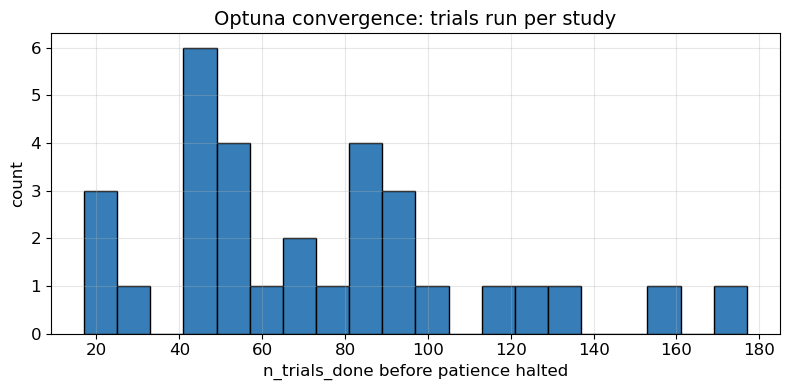

  Plot: cell_m6/M6_n_trials_hist_20260703_084520.png


In [8]:
# @title CELL M6: CONVERGENCE (trials done vs requested)
print("=" * 70)
print("CELL M6: CONVERGENCE BEHAVIOUR")
print("=" * 70)

if len(BP_DF) == 0:
    print("  Empty BP_DF; skipping.")
else:
    conv_cols = ['notebook', 'manifest_key', 'classifier', 'tuned_auc', 'baseline_auc',
                 'delta_auc', 'n_trials_done', 'n_trials_requested', 'patience']
    conv_cols = [c for c in conv_cols if c in BP_DF.columns]
    CONV_DF = BP_DF[conv_cols].copy()
    if 'n_trials_done' in CONV_DF.columns and 'n_trials_requested' in CONV_DF.columns:
        CONV_DF['early_stopped'] = (CONV_DF['n_trials_done'] < CONV_DF['n_trials_requested'])
    display(CONV_DF.sort_values('n_trials_done'))
    save_result(CONV_DF, 'M6_convergence', 'cell_m6')

    # Histogram of trials_done
    try:
        if 'n_trials_done' in CONV_DF.columns:
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.hist(CONV_DF['n_trials_done'].dropna(), bins=20, color='#377eb8',
                    edgecolor='black')
            ax.set_xlabel('n_trials_done before patience halted')
            ax.set_ylabel('count')
            ax.set_title('Optuna convergence: trials run per study')
            ax.grid(alpha=0.3)
            fig.tight_layout()
            save_fig(fig, 'M6_n_trials_hist', 'cell_m6')
            plt.close(fig)
    except Exception as e:
        print(f"  Plot skipped: {e}")


## CELL M7 -- SUMMARY

In [9]:
# @title CELL M7: SUMMARY
print("=" * 70)
print("CELL M7: SUMMARY")
print("=" * 70)

summary = {
    'n_tuned_studies': int(len(BP_DF)),
    'n_classifiers_seen': int(BP_DF['classifier'].nunique()) if 'classifier' in BP_DF.columns else 0,
    'n_parquets_seen':   int(BP_DF['manifest_key'].nunique()) if 'manifest_key' in BP_DF.columns else 0,
}
if 'delta_auc' in BP_DF.columns:
    s = BP_DF['delta_auc'].dropna()
    if len(s) > 0:
        summary['delta_auc_mean']   = float(s.mean())
        summary['delta_auc_median'] = float(s.median())
        summary['delta_auc_max']    = float(s.max())
        summary['n_positive_lift']  = int((s > 0).sum())
if 'n_trials_done' in BP_DF.columns:
    s = BP_DF['n_trials_done'].dropna()
    if len(s) > 0:
        summary['n_trials_done_mean']   = float(s.mean())
        summary['n_trials_done_median'] = float(s.median())
        summary['n_trials_done_max']    = int(s.max())

print(_json.dumps(summary, indent=2))
save_result(summary, 'summary', 'cell_m7', fmt='json')
print("\n  NB11f complete.")


CELL M7: SUMMARY
{
  "n_tuned_studies": 31,
  "n_classifiers_seen": 5,
  "n_parquets_seen": 19,
  "delta_auc_mean": 0.02974555034397947,
  "delta_auc_median": 0.03024485932233445,
  "delta_auc_max": 0.16066299594257472,
  "n_positive_lift": 30,
  "n_trials_done_mean": 72.7741935483871,
  "n_trials_done_median": 65.0,
  "n_trials_done_max": 177
}
  Saved: cell_m7/summary_20260703_084520.json (0.3 KB)

  NB11f complete.
